<a href="https://colab.research.google.com/github/Aryaf-AI/Movie-assistant-Chatbot/blob/main/movie_assistant_chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Assistant Chatbot
**AINT-361 | NLP & Deep Learning Project**

This notebook builds a movie recommendation chatbot using:
- **Intent Classification**: Bidirectional LSTM
- **Response Generation**: Retrieval-based (TF-IDF + Cosine Similarity)

---

## ⚙️ Step 0: Install & Import Dependencies

In [ ]:
!pip install nltk tensorflow scikit-learn matplotlib seaborn --quiet

In [ ]:
!pip install gradio --quiet

In [ ]:
import json
import random
import numpy as np
import nltk
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [ ]:
import gradio as gr

---
## 📁 Step 1: Dataset — intents.json
> **To customize**: Edit the `intents` list below. Each intent has:
> - `tag`: unique intent name
> - `patterns`: example user sentences
> - `responses`: bot replies for that intent

In [ ]:
intents_data = {
    "intents": [
        {
            "tag": "greeting",
            "patterns": [
                "Hi", "Hello", "Hey", "Good morning", "Good evening",
                "Howdy", "What's up", "Greetings", "Hi there", "Hello bot"
            ],
            "responses": [
                "Hello! I'm your Movie Assistant 🎬 How can I help you today?",
                "Hey there! Ready to find your next favorite movie?",
                "Hi! Ask me about movies, genres, or recommendations!"
            ]
        },
        {
            "tag": "goodbye",
            "patterns": [
                "Bye", "Goodbye", "See you later", "Take care",
                "I'm leaving", "Exit", "Quit", "That's all", "Thanks bye", "Cya"
            ],
            "responses": [
                "Goodbye! Enjoy your movie! 🍿",
                "See you next time! Happy watching!",
                "Bye! Hope you find a great film!"
            ]
        },
        {
            "tag": "recommend_action",
            "patterns": [
                "Recommend an action movie", "I want to watch action",
                "Best action films", "Suggest action movies", "Action movie recommendation",
                "Give me a thriller action film", "Top action movies",
                "I love action movies", "What action film should I watch",
                "Any good action movies?"
            ],
            "responses": [
                "🎬 Try Mad Max: Fury Road (2015) — pure high-octane cinema!",
                "🎬 John Wick (2014) is a masterclass in action choreography.",
                "🎬 Die Hard (1988) — a timeless action classic!",
                "🎬 Mission Impossible: Fallout (2018) has jaw-dropping stunts."
            ]
        },
        {
            "tag": "recommend_comedy",
            "patterns": [
                "Recommend a comedy", "I want to laugh", "Funny movies",
                "Best comedies", "Suggest a comedy film", "Comedy movie recommendation",
                "What's a good comedy", "I feel like watching something funny",
                "Any hilarious movies", "Make me laugh with a movie"
            ],
            "responses": [
                "😂 The Grand Budapest Hotel (2014) is witty and visually stunning!",
                "😂 Superbad (2007) — a hilarious coming-of-age comedy.",
                "😂 Game Night (2018) is a perfect comedy for a fun evening!",
                "😂 Knives Out (2019) blends comedy and mystery brilliantly."
            ]
        },
        {
            "tag": "recommend_horror",
            "patterns": [
                "Recommend a horror movie", "I want to be scared", "Best horror films",
                "Scary movie suggestion", "Horror movie recommendation",
                "What horror should I watch", "Good horror films",
                "I like scary movies", "Suggest a scary film", "Any creepy movies"
            ],
            "responses": [
                "👻 Get Out (2017) is a psychological horror masterpiece!",
                "👻 Hereditary (2018) will genuinely disturb you.",
                "👻 The Conjuring (2013) is a modern horror classic.",
                "👻 A Quiet Place (2018) — suspense at its finest!"
            ]
        },
        {
            "tag": "recommend_romance",
            "patterns": [
                "Recommend a romance movie", "I want a love story", "Best romantic films",
                "Romantic movie suggestion", "Romance recommendation",
                "Sweet love movies", "Suggest a romantic film",
                "I feel romantic", "Any good love movies", "Valentine movie ideas"
            ],
            "responses": [
                "💕 La La Land (2016) is a beautiful romantic musical drama.",
                "💕 The Notebook (2004) — a timeless love story.",
                "💕 About Time (2013) is heartwarming and touching.",
                "💕 Crazy, Stupid, Love (2011) is charming and funny!"
            ]
        },
        {
            "tag": "recommend_scifi",
            "patterns": [
                "Recommend a sci-fi movie", "I like science fiction", "Best sci-fi films",
                "Science fiction recommendation", "Space movies", "Futuristic movies",
                "Suggest a sci-fi film", "Any good space movies",
                "I want to watch sci-fi", "Top science fiction movies"
            ],
            "responses": [
                "🚀 Interstellar (2014) is a breathtaking space epic!",
                "🚀 Blade Runner 2049 (2017) — visually stunning sci-fi.",
                "🚀 Arrival (2016) is a thought-provoking masterpiece.",
                "🚀 The Martian (2015) — survival science fiction at its best!"
            ]
        },
        {
            "tag": "recommend_animation",
            "patterns": [
                "Recommend an animated movie", "Best animated films", "Cartoon movie suggestion",
                "Animation recommendation", "Good movies for kids", "Family animated films",
                "Disney or Pixar movies", "Suggest an animated film",
                "Animated movie to watch", "Pixar recommendations"
            ],
            "responses": [
                "🎨 Spider-Man: Into the Spider-Verse (2018) is a visual revolution!",
                "🎨 Coco (2017) — a heartfelt Pixar gem.",
                "🎨 Spirited Away (2001) is a timeless animated classic.",
                "🎨 The Lion King (1994) — pure animated magic!"
            ]
        },
        {
            "tag": "movie_info",
            "patterns": [
                "Tell me about Inception", "What is Interstellar about",
                "Describe The Dark Knight", "Movie details", "What's the plot of Titanic",
                "Give me info on Avengers", "What is The Matrix about",
                "Tell me about Parasite", "Describe the movie Joker",
                "What's the story of Forrest Gump"
            ],
            "responses": [
                "You can find detailed movie info on IMDb at https://www.imdb.com 🎬",
                "For full movie details, check Rotten Tomatoes at https://www.rottentomatoes.com",
                "Great choice! I'd suggest checking IMDb for in-depth info on that film."
            ]
        },
        {
            "tag": "top_rated",
            "patterns": [
                "What are the best movies ever", "Top rated movies", "Greatest films of all time",
                "Highest rated movies", "All time best movies", "Oscar winning movies",
                "Award winning films", "Most acclaimed movies", "Classic movies list",
                "What movies won oscars"
            ],
            "responses": [
                "🏆 All-time greats: The Shawshank Redemption, The Godfather, Schindler's List, and Parasite!",
                "🏆 Oscar winners to watch: Oppenheimer (2023), CODA (2021), Nomadland (2020).",
                "🏆 IMDb Top 3: The Shawshank Redemption, The Godfather, and The Dark Knight!"
            ]
        },
        {
            "tag": "new_releases",
            "patterns": [
                "What movies are out now", "New movie releases", "Latest movies",
                "Recent movies", "What's new in cinema", "Newly released films",
                "Movies in theaters now", "What came out this year",
                "Best movies of 2024", "New films to watch"
            ],
            "responses": [
                "🆕 Check out Dune: Part Two and Deadpool & Wolverine for recent blockbusters!",
                "🆕 For the latest releases, visit https://www.imdb.com/movies-in-theaters/",
                "🆕 Recent must-watches: Oppenheimer, Poor Things, and The Holdovers!"
            ]
        },
        {
            "tag": "bot_identity",
            "patterns": [
                "Who are you", "What are you", "Are you a bot", "What is your name",
                "Introduce yourself", "What can you do", "Tell me about yourself",
                "Are you human", "What's your purpose", "How can you help me"
            ],
            "responses": [
                "🎬 I'm Movie Assistant, your personal film guide! I can recommend movies by genre, tell you about top-rated films, and more!",
                "I'm a chatbot built with NLP and Deep Learning to help you discover amazing movies! 🍿"
            ]
        }
    ]
}

# Save dataset to file
with open('intents.json', 'w') as f:
    json.dump(intents_data, f, indent=4)

print(f'✅ Dataset saved! Total intents: {len(intents_data["intents"])}')
for intent in intents_data['intents']:
    print(f"  • {intent['tag']}: {len(intent['patterns'])} patterns")

✅ Dataset saved! Total intents: 12
  • greeting: 10 patterns
  • goodbye: 10 patterns
  • recommend_action: 10 patterns
  • recommend_comedy: 10 patterns
  • recommend_horror: 10 patterns
  • recommend_romance: 10 patterns
  • recommend_scifi: 10 patterns
  • recommend_animation: 10 patterns
  • movie_info: 10 patterns
  • top_rated: 10 patterns
  • new_releases: 10 patterns
  • bot_identity: 10 patterns


---
## 🔍 Step 2: NLP Preprocessing

In [ ]:
nltk.download('punkt_tab', quiet=True)

def preprocess_text(text):
    """Tokenize, lowercase, lemmatize, and remove stopwords."""
    tokens = nltk.word_tokenize(text.lower())
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in stop_words
    ]
    return ' '.join(tokens)

# ── Build corpus ──────────────────────────────────────────────────────────────
corpus_raw   = []   # original patterns
corpus_clean = []   # preprocessed patterns
labels       = []   # intent tags

for intent in intents_data['intents']:
    for pattern in intent['patterns']:
        corpus_raw.append(pattern)
        corpus_clean.append(preprocess_text(pattern))
        labels.append(intent['tag'])

print(f'✅ Total training samples: {len(corpus_clean)}')
print('\nSample preprocessing:')
for i in [0, 10, 20]:
    print(f'  Original : {corpus_raw[i]}')
    print(f'  Processed: {corpus_clean[i]}')
    print()

✅ Total training samples: 120

Sample preprocessing:
  Original : Hi
  Processed: hi

  Original : Bye
  Processed: bye

  Original : Recommend an action movie
  Processed: recommend action movie



---
## 🤖 Step 3: Model Training — Bidirectional LSTM

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
VOCAB_SIZE   = 500
MAX_LEN      = 20
EMBED_DIM    = 64
LSTM_UNITS   = 128
DROPOUT_RATE = 0.4
BATCH_SIZE   = 8
EPOCHS       = 200

# ── Tokenization & Padding ────────────────────────────────────────────────────
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(corpus_clean)
sequences = tokenizer.texts_to_sequences(corpus_clean)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# ── Label Encoding ────────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(labels)
NUM_CLASSES   = len(label_encoder.classes_)
y             = to_categorical(y_encoded, num_classes=NUM_CLASSES)

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'Classes  : {list(label_encoder.classes_)}')
print(f'X_train  : {X_train.shape}  |  X_test: {X_test.shape}')

Classes  : [np.str_('bot_identity'), np.str_('goodbye'), np.str_('greeting'), np.str_('movie_info'), np.str_('new_releases'), np.str_('recommend_action'), np.str_('recommend_animation'), np.str_('recommend_comedy'), np.str_('recommend_horror'), np.str_('recommend_romance'), np.str_('recommend_scifi'), np.str_('top_rated')]
X_train  : (96, 20)  |  X_test: (24, 20)


In [ ]:
# ── Model Architecture ────────────────────────────────────────────────────────
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
              input_length=MAX_LEN, name='embedding'),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True), name='bi_lstm'),
    GlobalMaxPooling1D(name='global_max_pool'),
    Dense(64, activation='relu', name='dense_1'),
    Dropout(DROPOUT_RATE, name='dropout'),
    Dense(NUM_CLASSES, activation='softmax', name='output')
], name='MovieAssistant_BiLSTM')

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model.summary()

Model: "MovieAssistant_BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=20,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-5, verbose=1)
]

# ── Training ──────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

model.save('movie_assistant_model.h5')
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print('\n✅ Model saved!')

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.0833 - loss: 2.4900 - val_accuracy: 0.0833 - val_loss: 2.4837 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0729 - loss: 2.4819 - val_accuracy: 0.0833 - val_loss: 2.4811 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1146 - loss: 2.4752 - val_accuracy: 0.0833 - val_loss: 2.4778 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1250 - loss: 2.4680 - val_accuracy: 0.1250 - val_loss: 2.4682 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1250 - loss: 2.4465 - val_accuracy: 0.1667 - val_loss: 2.4484 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1458 - loss: 2.4124 - val_accuracy: 0.1667 - val_loss: 2.4026 - learning_rate: 0.0010
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2396 - loss: 2.2896 -


✅ Model saved!


---
## 📊 Step 4: Training Curves

/tmp/ipykernel_40060/191738857.py:18: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40060/191738857.py:19: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


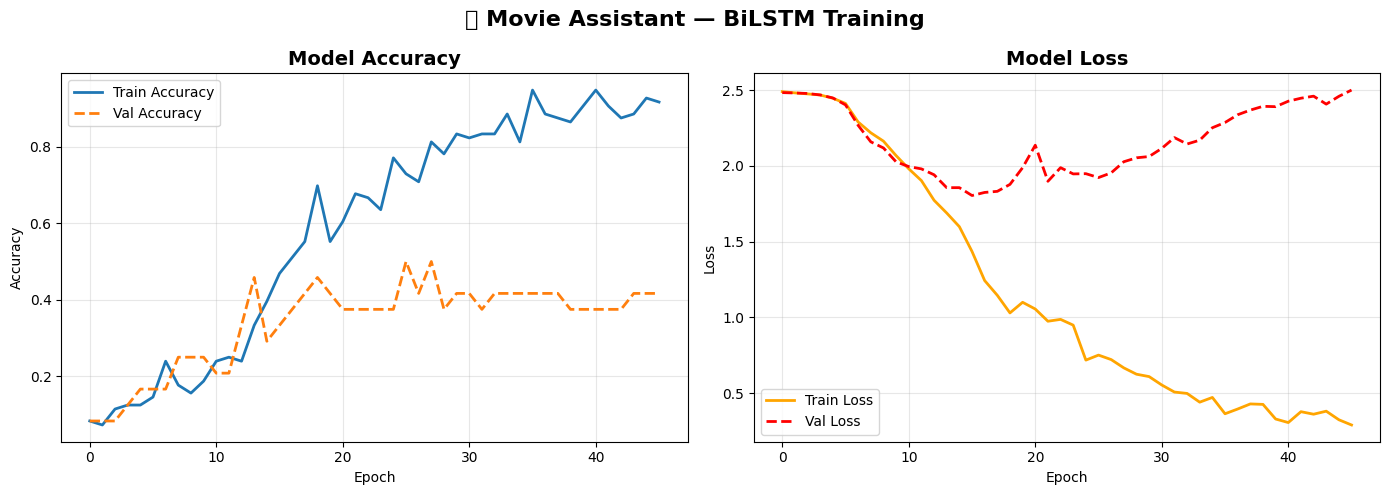

✅ Training curves saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2, color='orange')
axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--', color='red')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('🎬 Movie Assistant — BiLSTM Training', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Training curves saved.')

---
## 📈 Step 5: Performance Evaluation

In [ ]:
# ── Classification Report ─────────────────────────────────────────────────────
y_pred_proba = model.predict(X_test)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = np.argmax(y_test,       axis=1)

print('=' * 60)
print('          CLASSIFICATION REPORT')
print('=' * 60)
print(classification_report(
    y_true, y_pred,
    target_names=label_encoder.classes_
))

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy : {acc * 100:.2f}%')
print(f'Test Loss     : {loss:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
          CLASSIFICATION REPORT
                     precision    recall  f1-score   support

       bot_identity       0.50      0.50      0.50         2
            goodbye       0.00      0.00      0.00         2
           greeting       0.50      0.50      0.50         2
         movie_info       0.33      0.50      0.40         2
       new_releases       0.25      0.50      0.33         2
   recommend_action       0.67      1.00      0.80         2
recommend_animation       1.00      0.50      0.67         2
   recommend_comedy       1.00      0.50      0.67         2
   recommend_horror       0.50      0.50      0.50         2
  recommend_romance       1.00      0.50      0.67         2
    recommend_scifi       0.40      1.00      0.57         2
          top_rated       0.00      0.00      0.00         2

           accuracy                           0.50        24
          macro avg       0.51      0.50      0.47        24
       weigh

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy : 50.00%
Test Loss     : 1.9230


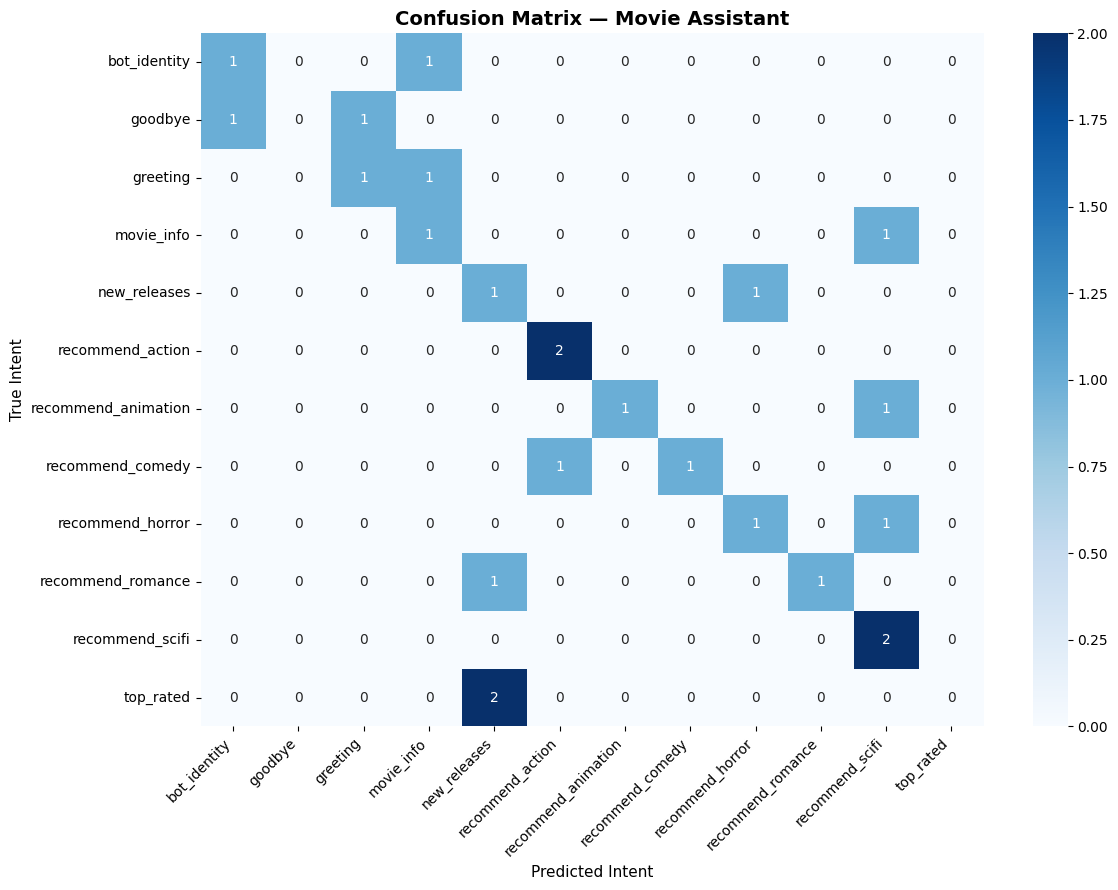

✅ Confusion matrix saved.


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix — Movie Assistant', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Intent', fontsize=11)
plt.ylabel('True Intent',      fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrix saved.')

---
## 🔁 Step 6: Retrieval-Based Response (TF-IDF + Cosine Similarity)

In [ ]:
# Build TF-IDF matrix over all patterns
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix     = tfidf_vectorizer.fit_transform(corpus_clean)

def get_tfidf_response(user_input, predicted_tag, threshold=0.05):
    """
    Uses cosine similarity to find the closest pattern,
    then returns a response from the matched intent.
    Falls back to predicted_tag responses if similarity is low.
    """
    user_vec  = tfidf_vectorizer.transform([preprocess_text(user_input)])
    sims      = cosine_similarity(user_vec, tfidf_matrix).flatten()
    best_idx  = np.argmax(sims)
    best_sim  = sims[best_idx]
    best_tag  = labels[best_idx]

    # Use cosine-matched tag if similarity is high enough
    chosen_tag = best_tag if best_sim >= threshold else predicted_tag

    for intent in intents_data['intents']:
        if intent['tag'] == chosen_tag:
            return random.choice(intent['responses'])

    return "Sorry, I didn't understand that. Try asking about a movie genre! 🎬"

print('✅ TF-IDF retrieval engine ready!')

✅ TF-IDF retrieval engine ready!


---
## 💬 Step 7: Chatbot Engine

In [ ]:
CONFIDENCE_THRESHOLD = 0.40

def predict_intent(user_input):
    """Classify user input with the BiLSTM model."""
    cleaned  = preprocess_text(user_input)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs    = model.predict(padded, verbose=0)[0]
    idx      = np.argmax(probs)
    tag      = label_encoder.inverse_transform([idx])[0]
    conf     = float(probs[idx])
    return tag, conf


def chatbot_response(user_input):
    """Full pipeline: classify → retrieve → respond."""
    tag, conf = predict_intent(user_input)

    if conf < CONFIDENCE_THRESHOLD:
        return (
            "Hmm, I'm not sure about that. Try asking me to recommend "
            "an action, comedy, horror, romance, or sci-fi movie! 🎬"
        )
    return get_tfidf_response(user_input, tag)


print('✅ Chatbot engine ready!')

✅ Chatbot engine ready!


---
## 🎬 Step 8: Chat Interface

In [ ]:
print('=' * 60)
print('       🎬  MOVIE ASSISTANT CHATBOT  🎬')
print('       Type "quit" or "exit" to stop')
print('=' * 60)

while True:
    user_input = input('\nYou: ').strip()

    if not user_input:
        continue

    if user_input.lower() in ['quit', 'exit', 'bye', 'goodbye']:
        print('Bot: Goodbye! Enjoy your movie! 🍿')
        break

    tag, conf = predict_intent(user_input)
    response  = chatbot_response(user_input)

    print(f'Bot: {response}')
    print(f'     [Intent: {tag} | Confidence: {conf:.2%}]')

       🎬  MOVIE ASSISTANT CHATBOT  🎬
       Type "quit" or "exit" to stop

You: hi
Bot: Hi! Ask me about movies, genres, or recommendations!
     [Intent: greeting | Confidence: 72.61%]

You: i want comedy movie
Bot: 😂 Game Night (2018) is a perfect comedy for a fun evening!
     [Intent: recommend_scifi | Confidence: 41.02%]


KeyboardInterrupt: Interrupted by user

---

## 🚀 Step 9: Launch Gradio Interface

In [ ]:
def gradio_chatbot_interface(user_message):
    return chatbot_response(user_message)

interface = gr.Interface(
    fn=gradio_chatbot_interface,
    inputs=gr.Textbox(lines=2, placeholder="Type your movie query here..."),
    outputs=gr.Textbox(label="Movie Assistant"),
    title="🎬 Movie Assistant Chatbot",
    description=(
        "Ask me about movie recommendations by genre (action, comedy, horror, romance, sci-fi, animation), "
        "top-rated movies, new releases, or general movie info!"
    ),
    allow_flagging="never"
)

interface.launch(debug=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e94971e253105d35c6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 🧪 Step 9: Quick Test (no typing needed)

In [ ]:
test_inputs = [
    "Hello!",
    "Recommend an action movie",
    "I want to watch something funny",
    "What are the best movies ever made?",
    "I love sci-fi and space films",
    "Suggest a scary horror movie",
    "Who are you?",
    "What new movies came out recently?",
    "I want a romantic film for tonight",
    "Bye"
]

print('=' * 65)
print('                  🎬 QUICK TEST RUN')
print('=' * 65)

for q in test_inputs:
    tag, conf = predict_intent(q)
    resp      = chatbot_response(q)
    print(f'\n👤 User : {q}')
    print(f'🤖 Bot  : {resp}')
    print(f'         [Intent: {tag} | Confidence: {conf:.2%}]')

                  🎬 QUICK TEST RUN

👤 User : Hello!
🤖 Bot  : Hi! Ask me about movies, genres, or recommendations!
         [Intent: greeting | Confidence: 61.31%]

👤 User : Recommend an action movie
🤖 Bot  : 🎬 Try Mad Max: Fury Road (2015) — pure high-octane cinema!
         [Intent: recommend_action | Confidence: 98.83%]

👤 User : I want to watch something funny
🤖 Bot  : Hmm, I'm not sure about that. Try asking me to recommend an action, comedy, horror, romance, or sci-fi movie! 🎬
         [Intent: recommend_romance | Confidence: 23.50%]

👤 User : What are the best movies ever made?
🤖 Bot  : 🏆 Oscar winners to watch: Oppenheimer (2023), CODA (2021), Nomadland (2020).
         [Intent: recommend_scifi | Confidence: 48.60%]

👤 User : I love sci-fi and space films
🤖 Bot  : 🚀 Arrival (2016) is a thought-provoking masterpiece.
         [Intent: recommend_romance | Confidence: 80.57%]

👤 User : Suggest a scary horror movie
🤖 Bot  : 👻 A Quiet Place (2018) — suspense at its finest!
         [